In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset=pd.read_csv("student_data.csv")
dataset.head()
dataset.columns
dataset.shape
dataset.describe()
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [3]:
#Checking null and duplicate values
dataset.isnull().sum()
dataset.duplicated().sum()

np.int64(0)

In [4]:
#Unique values
dataset["school"].unique()
dataset["sex"].unique()
dataset["address"].unique()
dataset["famsize"].unique()
dataset["Pstatus"].unique()
dataset["Mjob"].unique()
dataset["Fjob"].unique()
dataset["reason"].unique()
dataset["guardian"].unique()
dataset["schoolsup"].unique()
dataset["famsup"].unique()
dataset["paid"].unique()
dataset["activities"].unique()
dataset.head()
dataset.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
#EDA
dataset["G3"].value_counts().sort_index()
dataset["G3"].mean()
dataset[["G1", "G2", "G3"]].mean()

G1    10.908861
G2    10.713924
G3    10.415190
dtype: float64

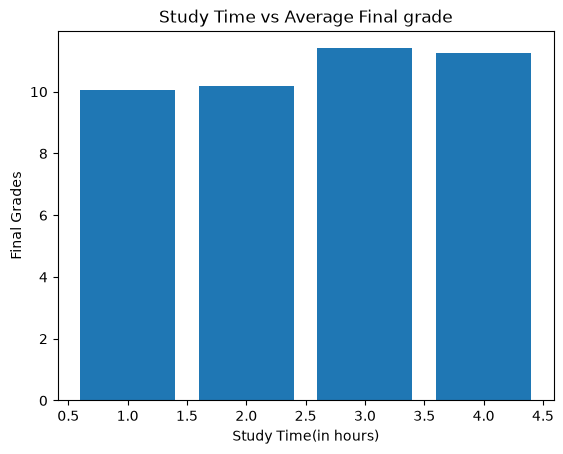

In [6]:
#Does studt Time has a relation with final grades
dataset["studytime"].value_counts().sort_index()
avg_grade=dataset.groupby("studytime")["G3"].mean()
plt.bar(avg_grade.index,avg_grade.values)
plt.title("Study Time vs Average Final grade")
plt.xlabel("Study Time(in hours)")
plt.ylabel("Final Grades")
plt.savefig("studyhours_vs_Finalgrade")
plt.show()


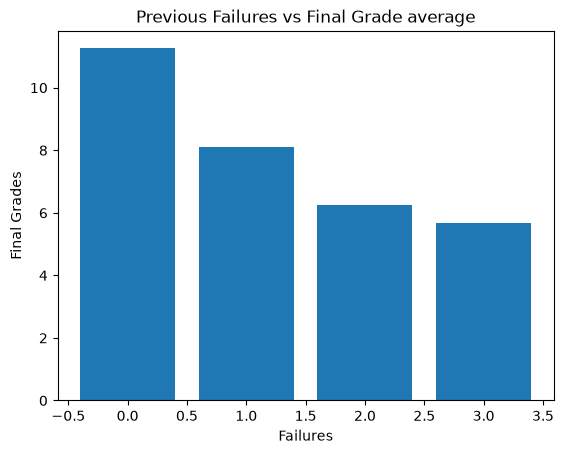

In [7]:
# Relation between previous failures and final grade
avg_failure_grade=dataset.groupby("failures")["G3"].mean()
plt.bar(avg_failure_grade.index,avg_failure_grade.values)
plt.title("Previous Failures vs Final Grade average")
plt.xlabel("Failures")
plt.ylabel("Final Grades")
plt.savefig("Previous Failures vs Average Final Grade")
plt.show()



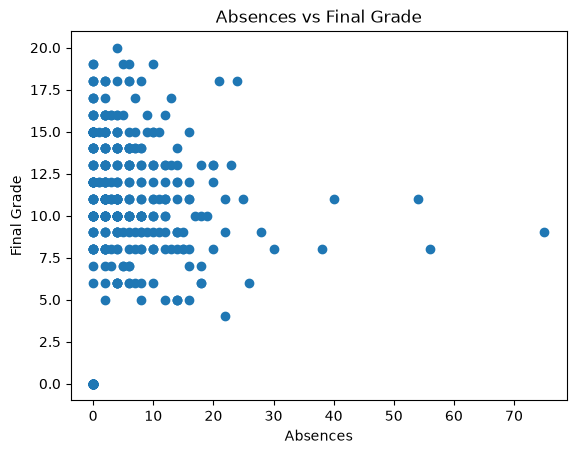

In [14]:
#Absences vs Average Final Grade
correlation=dataset["absences"].corr(dataset["G3"])
plt.scatter(dataset["absences"], dataset["G3"])
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.savefig("Absences_vs_final_Grade")
plt.show()

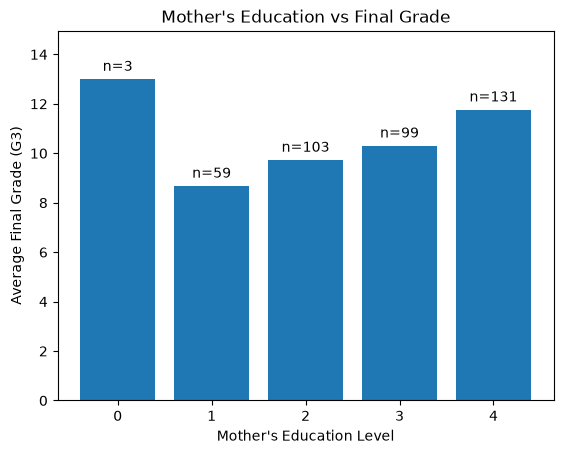

In [70]:
#Mother Education vs Final Grades
dataset["Medu"].value_counts().sort_index()
student_count = dataset["Medu"].value_counts().sort_index()
avg_grade_medu=dataset.groupby("Medu")["G3"].mean()
plt.bar(avg_grade_medu.index, avg_grade_medu.values)
for i,count in enumerate(student_count):
    avgg_grade= avg_grade_medu.values[i]
    plt.text(i, avgg_grade + 0.2, f"n={count}", ha='center', va='bottom')
plt.margins(y=0.15)

plt.xlabel("Mother's Education Level")
plt.ylabel("Average Final Grade (G3)")
plt.title("Mother's Education vs Final Grade")
plt.savefig("Mother's Education vs Final Grade")
plt.show()

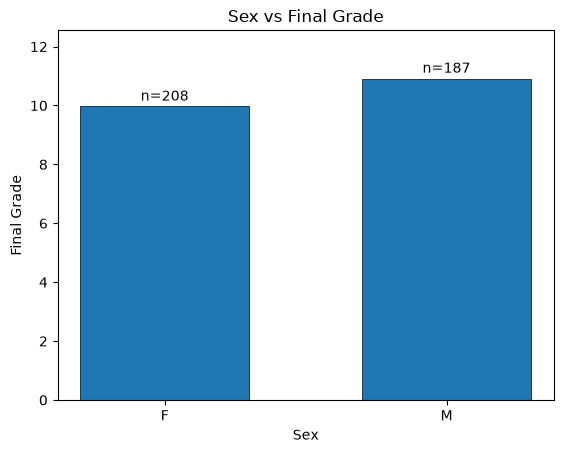

In [84]:
#Sex vs Final Grades
value_count=dataset["sex"].value_counts()
sex_relation=dataset.groupby("sex")["G3"].mean()
plt.bar(sex_relation.index,sex_relation.values,width=0.6,edgecolor="black",linewidth=0.5)
for i,count in enumerate(value_count):
    avg_grade=sex_relation.values[i]
    plt.text(i,avg_grade+0.2,f"n={count}",ha="center")
plt.margins(y=0.15)
plt.title("Sex vs Final Grade")
plt.xlabel("Sex")
plt.ylabel("Final Grade")
plt.savefig("Sex vs Final Grade")
plt.show()

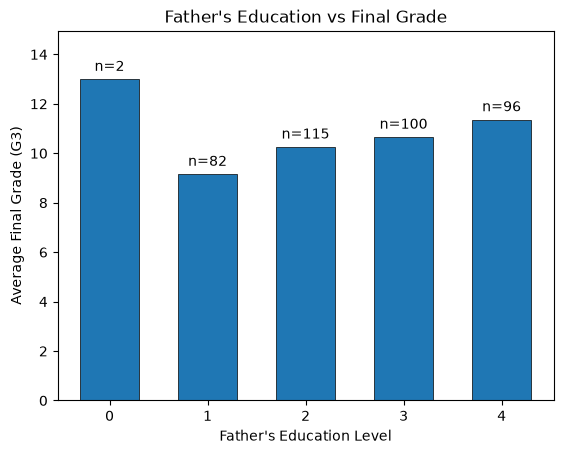

In [65]:
#FAther Education vs Final Grade
dataset["Fedu"].value_counts().sort_index()
student_count = dataset["Fedu"].value_counts().sort_index()
avg_grade_Fedu=dataset.groupby("Fedu")["G3"].mean()
plt.bar(avg_grade_Fedu.index, avg_grade_Fedu.values,edgecolor="black",linewidth=0.5,width=0.6)
for i,count in enumerate(student_count):
    avgg_grade= avg_grade_Fedu.values[i]
    plt.text(i, avgg_grade + 0.2, f"n={count}", ha='center', va='bottom')
plt.margins(y=0.15)
plt.xlabel("Father's Education Level")
plt.ylabel("Average Final Grade (G3)")
plt.title("Father's Education vs Final Grade")
plt.savefig("Father's Education vs Final Grade")
plt.show()

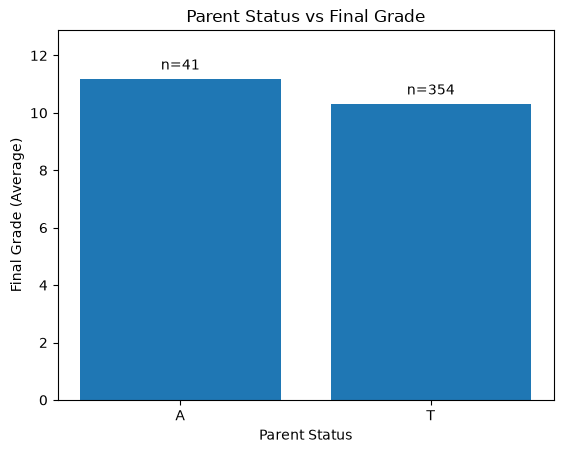

In [62]:

# Parent Status vs Final Grade
parent_status_count = dataset["Pstatus"].value_counts().sort_index()
parent_status = dataset.groupby("Pstatus")["G3"].mean().sort_index() 
plt.bar(parent_status.index, parent_status.values)
for i, count in enumerate(parent_status_count):
    avg_grade = parent_status.values[i]
    plt.text(i, avg_grade + 0.2, f"n={count}", ha='center', va='bottom')
plt.margins(y=0.15)

plt.title("Parent Status vs Final Grade")
plt.xlabel("Parent Status")
plt.ylabel("Final Grade (Average)")
plt.savefig("Parent status vs Final Grade")
plt.show()



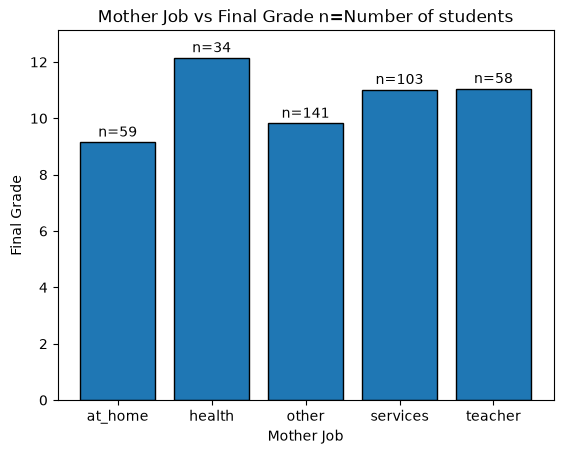

In [83]:
# Mother Job
student_count=dataset["Mjob"].value_counts().sort_index()
mother_job_effect=dataset.groupby("Mjob")["G3"].mean()
plt.bar(mother_job_effect.index,mother_job_effect.values,edgecolor="black")
for i,count in enumerate(student_count):
    yvalue=mother_job_effect.values[i]
    plt.text(i,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.08)
plt.title("Mother Job vs Final Grade n=Number of students")
plt.xlabel("Mother Job")
plt.ylabel("Final Grade")
plt.savefig("Mother Job vs Final grade")
plt.show()


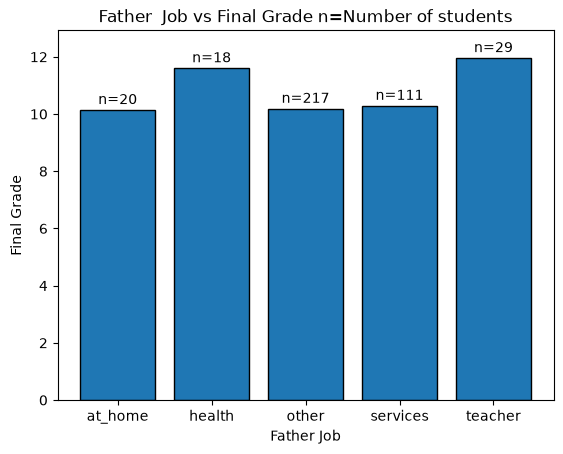

In [85]:
# Father Job vs Final Grade
student_count=dataset["Fjob"].value_counts().sort_index()
father_job_effect=dataset.groupby("Fjob")["G3"].mean()
plt.bar(father_job_effect.index,father_job_effect.values,edgecolor="black")
for i,count in enumerate(student_count):
    yvalue=father_job_effect.values[i]
    plt.text(i,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.08)
plt.title("Father  Job vs Final Grade n=Number of students")
plt.xlabel("Father Job")
plt.ylabel("Final Grade")
plt.savefig("Father Job vs Final grade")
plt.show()

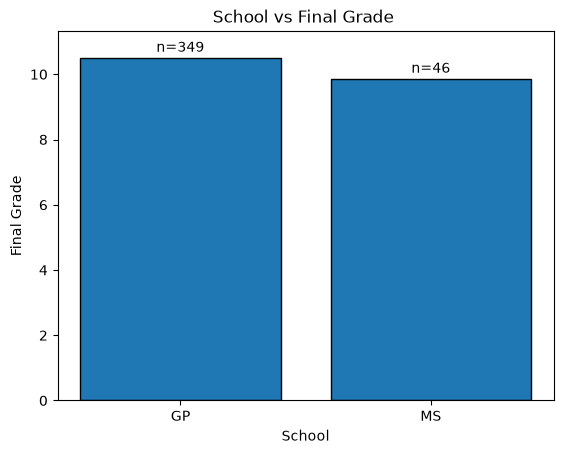

In [89]:
# Schools vs Final Grade
student_count=dataset["school"].value_counts().sort_index()
school_effect=dataset.groupby("school")["G3"].mean()
plt.bar(school_effect.index,school_effect.values,edgecolor="black")
for i,count in enumerate(student_count):
    yvalue=school_effect.values[i]
    plt.text(i,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.08)
plt.title("School vs Final Grade ")
plt.xlabel("School")
plt.ylabel("Final Grade")
plt.savefig("School vs Final grade")
plt.show()

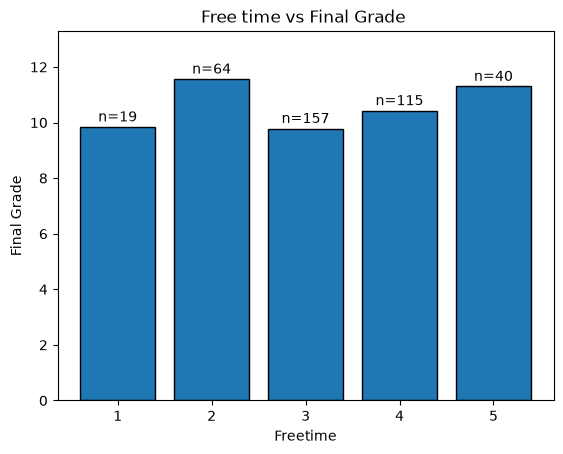

In [109]:
# Free Time vs Final Grade
student_count=dataset["freetime"].value_counts().sort_index()
freetime_effect=dataset.groupby("freetime")["G3"].mean().sort_index()
plt.bar(freetime_effect.index,freetime_effect.values,edgecolor="black")
for category,count in student_count.items():
    yvalue=freetime_effect[category]
    plt.text(category,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.15)

plt.title("Free time vs Final Grade ")
plt.xlabel("Freetime")
plt.ylabel("Final Grade")
plt.savefig("Freetime vs Final grade")
plt.show()

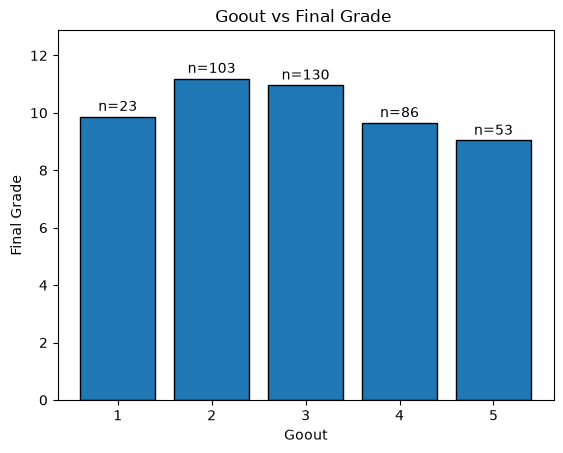

In [108]:
# Go out vs Final Grade
student_count=dataset["goout"].value_counts().sort_index()
goout_effect=dataset.groupby("goout")["G3"].mean().sort_index()
plt.bar(goout_effect.index,goout_effect.values,edgecolor="black")
for category,count in student_count.items():
    yvalue=goout_effect[category]
    plt.text(category,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.15)

plt.title("Goout vs Final Grade ")
plt.xlabel("Goout")
plt.ylabel("Final Grade")
plt.savefig("Goout vs Final grade")
plt.show()

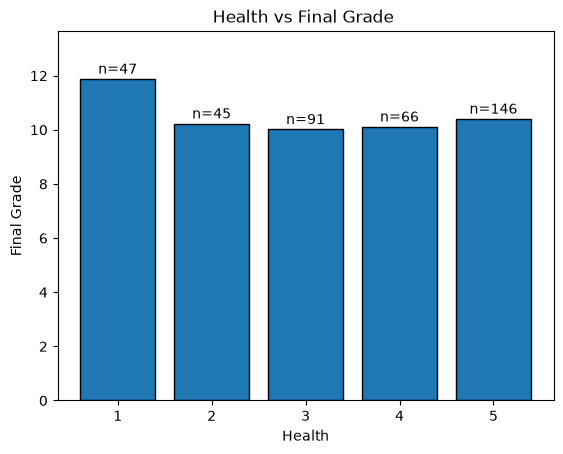

In [111]:
#Health vs Final Grade
student_count=dataset["health"].value_counts().sort_index()
health_effect=dataset.groupby("health")["G3"].mean().sort_index()
plt.bar(health_effect.index,health_effect.values,edgecolor="black")
for category,count in student_count.items():
    yvalue=health_effect[category]
    plt.text(category,yvalue+0.2,f"n={count}",ha="center")
plt.margins(y=0.15)

plt.title("Health vs Final Grade ")
plt.xlabel("Health")
plt.ylabel("Final Grade")
plt.savefig("Health vs Final grade")
plt.show()

In [51]:
dataset.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
